In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import plotly.express as px
import matplotlib.pyplot as plt 
%matplotlib inline 

sns.set(rc={"axes.facecolor":"Beige" , "axes.grid" : False})

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set Display 

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.precision', 2)

In [3]:
# Check Library Version

import numpy
print('numpy:{}'.format(numpy.__version__))

numpy:1.26.4


In [4]:
# Load the dataset

df = pd.read_csv("/kaggle/input/titanic/titanic.csv")
display(df.shape)
df.head()

(891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [5]:
# Set Table Properties

df.head(3).style.set_properties(**{'background-color': 'Black',
                           'color': 'White',
                           'border-color': 'darkblack',
                                  'font-size': '16px'})

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S


In [6]:
# Replacing Values/Names in a Column:

df1 = df.copy('Deep')
df1["Survived"].replace({0:"Died" , 1:"Saved"},inplace = True)
df1.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,Died,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,Saved,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
2,3,Saved,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S


In [7]:
# Drop Columns
df1 = df.copy('Deep')
df1 = df1.drop(['PassengerId','Ticket'],axis=1)
df1.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.25,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.28,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.92,NaN,S


In [8]:
# Drop Rows 

df = df.drop(labels=[1,3,5,7],axis=0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S


In [9]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [10]:
# Missing Value check

print('Method 1:')
df.isnull().sum()

Method 1:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            176
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          685
Embarked         2
dtype: int64

In [11]:
var1 = [col for col in df.columns if df[col].isnull().sum() != 0]
print(df[var1].isnull().sum())

Age         176
Cabin       685
Embarked      2
dtype: int64


Method 12:


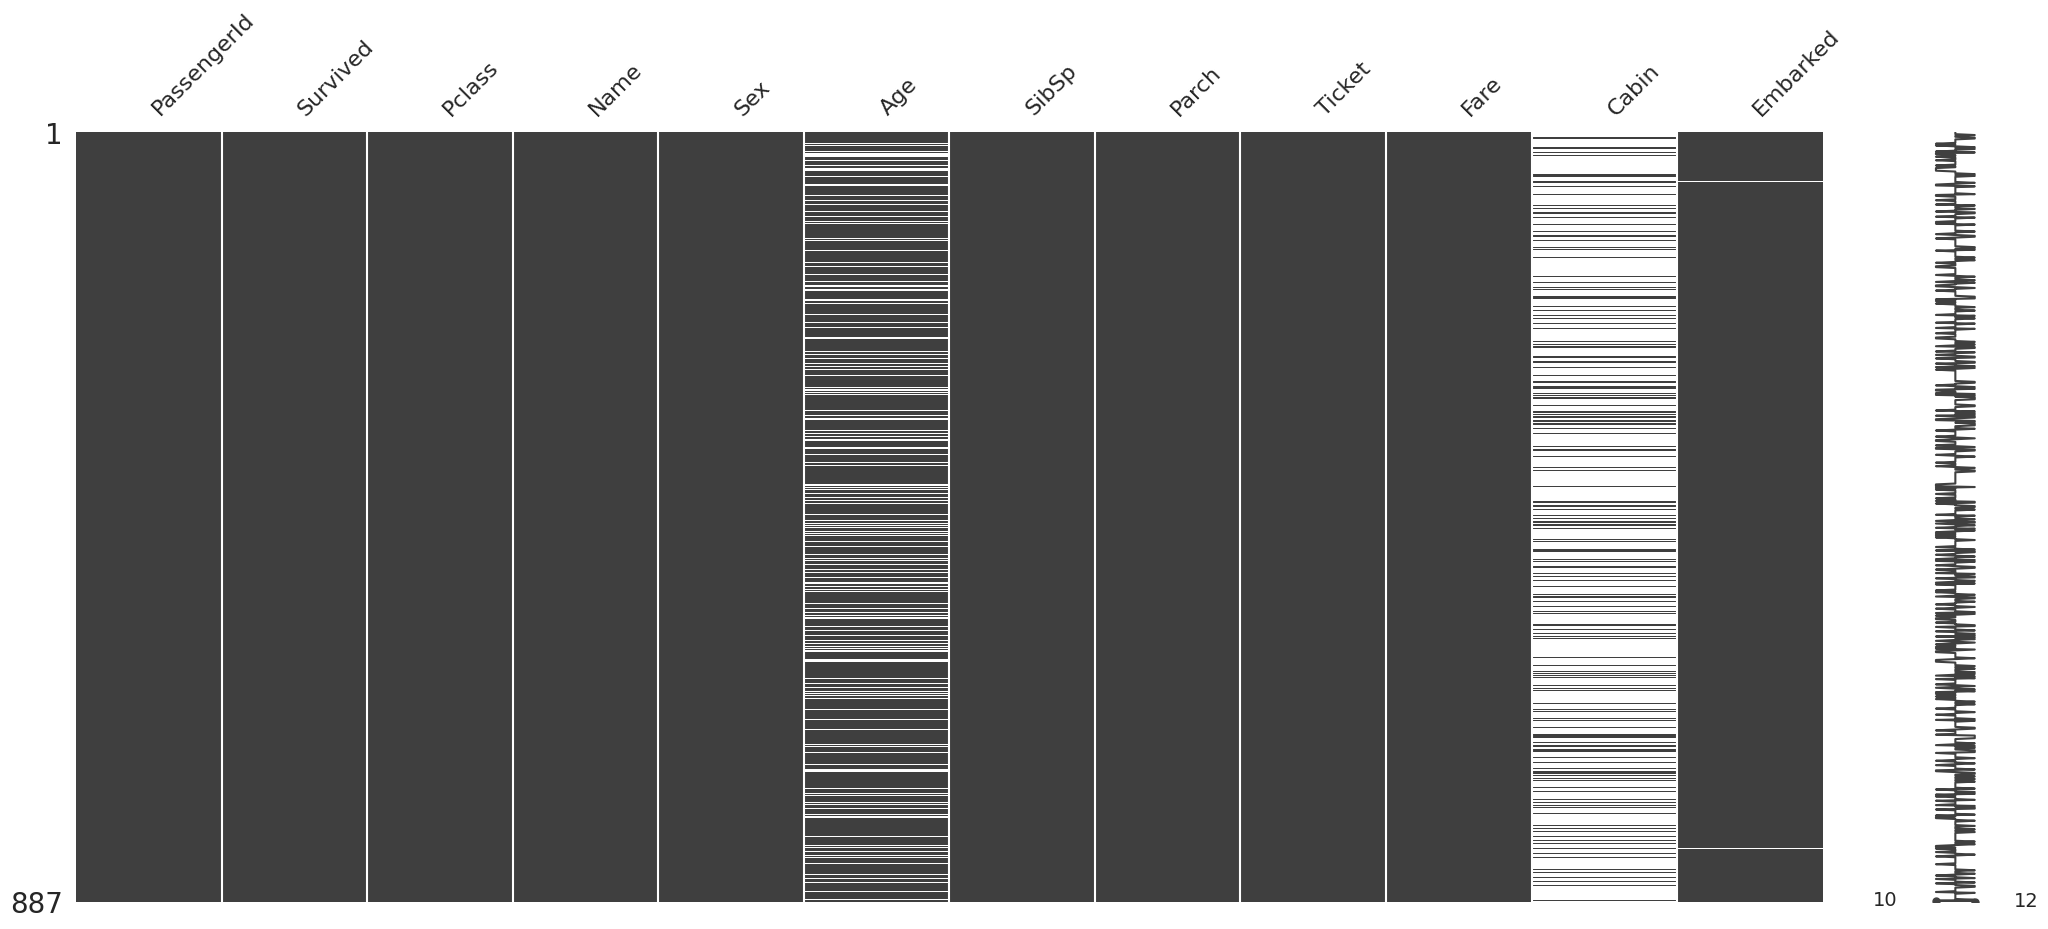

In [12]:
# Missing Value check

print('Method 12:')
import missingno as msno
msno.matrix(df)
plt.show()

In [13]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [14]:
sample_incomplete_rows =df[df.isnull().any(axis=1)].head()
sample_incomplete_rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,NaN,C


In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,887.00,887.00,887.00,711.00,887.00,887.00,887.00
mean,447.99,0.38,2.31,29.72,0.52,0.38,32.18
std,256.22,0.49,0.83,14.52,1.10,0.81,49.78
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,226.50,0.00,2.00,20.25,0.00,0.00,7.90
50%,448.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,669.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [16]:
# Describe
df[df['Survived']==0].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

,count,mean,std,min,25%,50%,75%,max
PassengerId,547.000000,448.625229,259.750818,1.000000,213.500000,457.000000,675.500000,891.000000
Survived,547.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pclass,547.000000,2.530165,0.736605,1.000000,2.000000,3.000000,3.000000,3.000000
Age,423.000000,30.693853,14.120135,1.000000,21.000000,28.000000,39.000000,74.000000
SibSp,547.000000,0.550274,1.286281,0.000000,0.000000,0.000000,1.000000,8.000000
Parch,547.000000,0.329068,0.824052,0.000000,0.000000,0.000000,0.000000,6.000000
Fare,547.000000,22.144765,31.440164,0.000000,7.854200,10.500000,26.000000,263.000000


In [17]:
df.describe(percentiles=[0.05,0.25,0.35,0.5,0.75,0.85,0.95,0.995,0.999])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,887.00,887.00,887.00,711.00,887.00,887.00,887.00
mean,447.99,0.38,2.31,29.72,0.52,0.38,32.18
std,256.22,0.49,0.83,14.52,1.10,0.81,49.78
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
5%,49.30,0.00,1.00,4.00,0.00,0.00,7.22
25%,226.50,0.00,2.00,20.25,0.00,0.00,7.90
35%,315.10,0.00,2.00,24.00,0.00,0.00,9.00
50%,448.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,669.50,1.00,3.00,38.00,1.00,0.00,31.00
85%,758.10,1.00,3.00,45.00,1.00,1.00,56.50


In [18]:
# Agg
df[['Age','Fare','Pclass']].agg(['sum','max','mean','std','skew','kurt'])

,Age,Fare,Pclass
sum,21130.17,28540.03,2049.00
max,80.00,512.33,3.00
mean,29.72,32.18,2.31
std,14.52,49.78,0.83
skew,0.40,4.79,-0.63
kurt,0.18,33.33,-1.27


In [19]:
# value_counts
df['Embarked'].value_counts().to_frame()

,count
Embarked,
S,642
C,167
Q,76


In [20]:
df['Embarked'].value_counts().tolist()

[642, 167, 76]

In [21]:
# value_counts for Multiple Columns
for col in df[['Survived','Sex','Embarked']]:
    print(df[col].value_counts().to_frame())
    print("****"*7)

          count
Survived       
0           547
1           340
****************************
        count
Sex          
male      575
female    312
****************************
          count
Embarked       
S           642
C           167
Q            76
****************************


In [22]:
#Count
df[['Age','Embarked','Sex']].count()

Age         711
Embarked    885
Sex         887
dtype: int64

In [23]:
df['Embarked'][df['Sex']=='female'].value_counts(normalize=True)*100

Embarked
S    65.16
C    23.23
Q    11.61
Name: proportion, dtype: float64

In [24]:
df['Embarked'].value_counts()/len(df['Embarked'])

Embarked
S    0.72
C    0.19
Q    0.09
Name: count, dtype: float64

In [25]:
#Shuffling the data
df2 = df.sample(frac=1,random_state=3)
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
733,734,0,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.00,NaN,S
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.05,NaN,S
161,162,1,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40.0,0,0,C.A. 33595,15.75,NaN,S
392,393,0,3,"Gustafsson, Mr. Johan Birger",male,28.0,2,0,3101277,7.92,NaN,S
614,615,0,3,"Brocklebank, Mr. William Alfred",male,35.0,0,0,364512,8.05,NaN,S


In [26]:
df1 = df.copy()

columns = ['Age']

for col in columns:
    df1[col].replace(0, np.NaN, inplace=True)
    
df1.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,887.00,887.00,887.00,711.00,887.00,887.00,887.00
mean,447.99,0.38,2.31,29.72,0.52,0.38,32.18
std,256.22,0.49,0.83,14.52,1.10,0.81,49.78
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,226.50,0.00,2.00,20.25,0.00,0.00,7.90
50%,448.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,669.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00e+00,-3.15e-03,-0.04,0.03,-0.05,-2.95e-03,0.01
Survived,-3.15e-03,1.00e+00,-0.33,-0.08,-0.04,8.35e-02,0.26
Pclass,-3.84e-02,-3.35e-01,1.00,-0.37,0.08,1.66e-02,-0.55
Age,3.49e-02,-8.15e-02,-0.37,1.00,-0.30,-1.87e-01,0.09
SibSp,-5.30e-02,-3.52e-02,0.08,-0.30,1.00,4.15e-01,0.16
Parch,-2.95e-03,8.35e-02,0.02,-0.19,0.41,1.00e+00,0.22
Fare,1.38e-02,2.56e-01,-0.55,0.09,0.16,2.17e-01,1.00


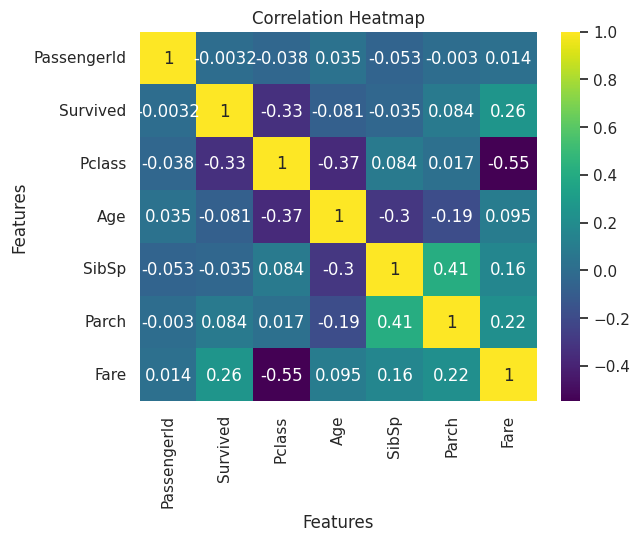

In [27]:
corr = df.select_dtypes('number').corr()
display(corr)

sns.heatmap(corr, annot=True, cmap='viridis')

plt.xlabel('Features')
plt.ylabel('Features')
plt.title('Correlation Heatmap')
plt.show()

Fare   Age
Embarked                 
C        Fare  1.00  0.16
         Age   0.16  1.00
Q        Fare  1.00  0.03
         Age   0.03  1.00
S        Fare  1.00  0.05
         Age   0.05  1.00

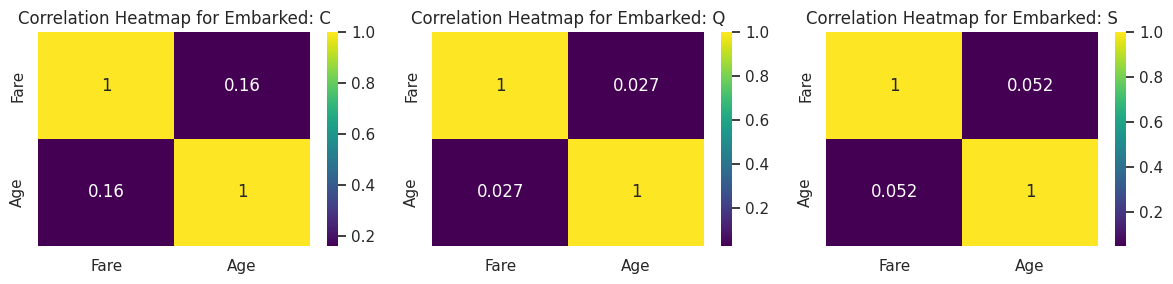

In [28]:
corr = df.groupby(["Embarked"])[["Fare", "Age"]].corr()
display(corr)

n_groups = len(corr.index.levels[0])

fig, axes = plt.subplots(nrows=1, ncols=min(3, n_groups), figsize=(12, 3))

group_count = 0
for embarked_group in corr.index.levels[0]:
    ax = axes.flat[group_count]
    sns.heatmap(corr.xs(embarked_group), annot=True, cmap='viridis', ax=ax)
    ax.set_title(f"Correlation Heatmap for Embarked: {embarked_group}")
    group_count += 1

plt.tight_layout()
plt.show()

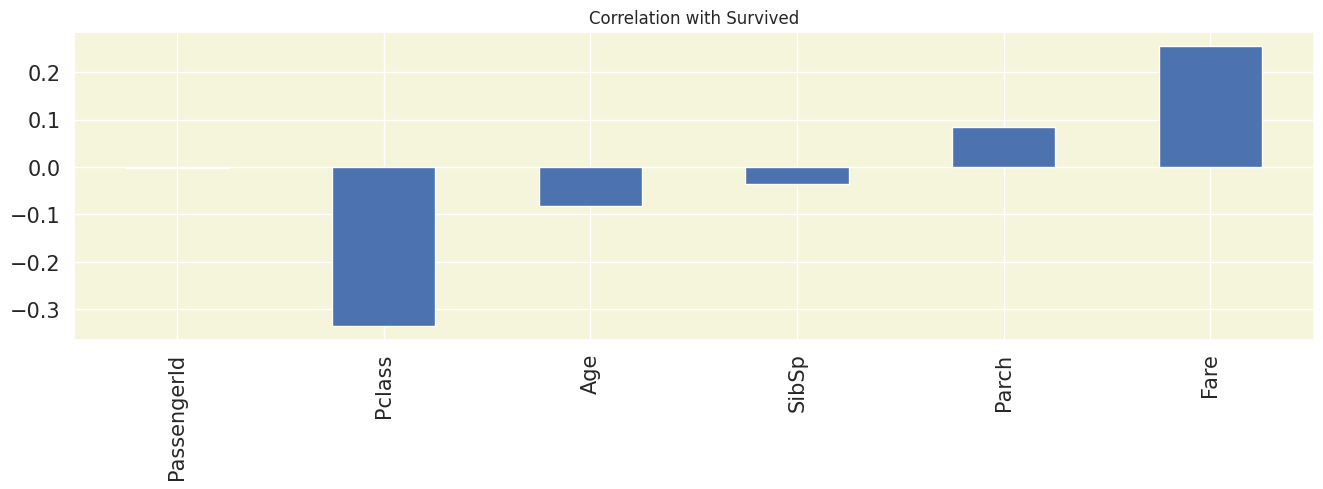

In [29]:
X = df.select_dtypes('number').drop(['Survived'],axis=1)
y = df.select_dtypes('number')['Survived']
X.corrwith(y).plot.bar(
        figsize = (16, 4), title = "Correlation with Survived", fontsize = 15,
        rot = 90, grid = True)
plt.show()

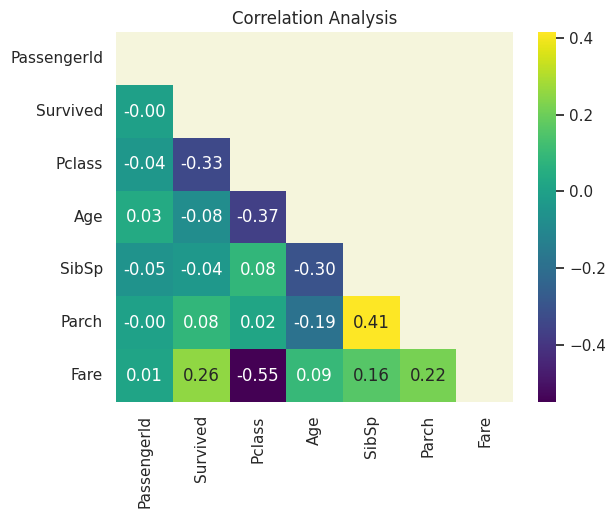

In [30]:
corr = df.select_dtypes('number').corr()
mask = np.triu(np.ones_like(corr,dtype = bool))
plt.figure(dpi=100)
plt.title('Correlation Analysis')
sns.heatmap(corr,mask=mask,annot=True,lw=0,linecolor='white',cmap='viridis',fmt = "0.2f")
plt.xticks(rotation=90)
plt.yticks(rotation = 0)
plt.show()

In [31]:
abs(df.select_dtypes('number').corr()).style.highlight_min(axis=0)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.003153,0.038432,0.034866,0.052966,0.002953,0.013752
Survived,0.003153,1.000000,0.334575,0.081455,0.035186,0.083506,0.255761
Pclass,0.038432,0.334575,1.000000,0.367249,0.083521,0.016574,0.548991
Age,0.034866,0.081455,0.367249,1.000000,0.304297,0.187338,0.094965
SibSp,0.052966,0.035186,0.083521,0.304297,1.000000,0.414724,0.159978
Parch,0.002953,0.083506,0.016574,0.187338,0.414724,1.000000,0.217091
Fare,0.013752,0.255761,0.548991,0.094965,0.159978,0.217091,1.000000


In [32]:
df1 = df1[df1['Cabin'].notna()]
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.00,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.50,A6,S


In [33]:
print('Passenger Survived in Titanic: {:d}'.format(df1['Survived'].value_counts()[0]))
print('Passenger Died in Titanic: {:d}'.format(df1['Survived'].value_counts()[1]))

Passenger Survived in Titanic: 68
Passenger Died in Titanic: 134


In [34]:
print('Survived sample ratio: {:.3f} %'.format(df1['Survived'].value_counts()[0]/len(df1)*100))
print('Died sample ratio: {:.3f} %'.format(df1['Survived'].value_counts()[1]/len(df1)*100))

Survived sample ratio: 33.663 %
Died sample ratio: 66.337 %


In [35]:
# Fillna Method

df1 = df.copy()
df1 = df1.dropna()

In [36]:
# Fillna Method

df1 = df.copy()
df1.fillna(method="ffill", inplace=True)

In [37]:
# Fill Null Values by Mean Value

df1 = df.copy()
df1["Age"] = df1["Age"].fillna(df1["Age"].mean())

In [38]:
# Fill Null Values by Desiresd Value

df1 = df.copy()
df1['Embarked'] = df1['Embarked'].fillna(df1['Embarked'] == 'Q')
df1.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [39]:
#Fill Method :
df1 = df.copy()
df1['Age'] = df1['Age'].fillna(0)
df1['Age'] = df1['Age'].fillna('None')
df1["Age"].fillna(method="backfill",inplace=True)
df1["Embarked"].fillna(value="A",inplace=True)
df1["Pclass"].fillna(value= 0,inplace=True)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S


In [40]:
# Find Method/Select Method

# Find All Null Values in the dataframe

df1 = df.copy()
df1 = df1.drop('Cabin',axis =1)

sample_incomplete_rows = df1[df1.isnull().any(axis=1)]
display(sample_incomplete_rows.shape)
sample_incomplete_rows.head()

(178, 11)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.00,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.22,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.22,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.88,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.90,S


In [41]:
titanic_Fare500 = df1[df1['Fare'] > 500][['Name','Embarked']]
display(titanic_Fare500.shape)
titanic_Fare500

(3, 2)

,Name,Embarked
258,"Ward, Miss. Anna",C
679,"Cardeza, Mr. Thomas Drake Martinez",C
737,"Lesurer, Mr. Gustave J",C


In [42]:
titanic_age_70 = df1.loc[df1['Age'] > 70, ["Name","Embarked","Sex"]]
display(titanic_age_70.shape)
titanic_age_70

(5, 3)

,Name,Embarked,Sex
96,"Goldschmidt, Mr. George B",C,male
116,"Connors, Mr. Patrick",Q,male
493,"Artagaveytia, Mr. Ramon",C,male
630,"Barkworth, Mr. Algernon Henry Wilson",S,male
851,"Svensson, Mr. Johan",S,male


In [43]:
titanic_age_selection = df[(df["Sex"] == "male") & (df["Age"] > 50.00)]
display(titanic_age_selection.shape)
titanic_age_selection.head()

(47, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.50,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.98,B30,C
94,95,0,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.25,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.65,A5,C


In [44]:
women = df1.loc[df1['Sex'] == 'female']["Survived"]
rate_women = (women.sum()/len(women)).round(3)*100
print("Percentage of women who survived:",rate_women,"%")

Percentage of women who survived: 74.0 %


In [45]:
men = df1.loc[df1['Sex'] == 'male']["Survived"]
rate_men = (men.sum()/len(men)).round(3)*100
print("Percentage of Men who survived:", rate_men,"%")

Percentage of Men who survived: 19.0 %


In [46]:
titanic_Pclass = df1[df1["Pclass"].isin([1, 2])]
display(titanic_Pclass.shape)
titanic_Pclass.head()

(398, 11)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,C
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.00,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.00,S


In [47]:
df1 = df.copy()
cabin_no_na = df1[df1["Cabin"].notna()]
display(cabin_no_na.shape)
cabin_no_na.head()

(202, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.00,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.50,A6,S


In [48]:
titanic_Pclass = df1[(df1["Pclass"] == 1) & (df1["Sex"] == 'female') & (df1["Age"] > 50 ) ]

display(titanic_Pclass.shape)
titanic_Pclass.head()

(13, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
195,196,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.52,B80,C
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.0,0,1,PC 17582,153.46,C125,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.96,D7,S
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.25,D37,C


In [49]:
# np.where

df1 = df.copy()
df1['Cabin_null'] = np.where(df1['Cabin'].isnull(),0,1)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_null
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0


In [50]:
df1 = df.copy()
df1["Bucket"] = np.where(df1["Fare"] < 250, "Low", "High")
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Bucket
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Low
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,Low
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,Low
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,Low
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,Low


In [51]:
df1 = df.copy()

titanic_age_missing_first  = df1.sort_values(by='Age',ascending=False, na_position='first')
titanic_age_missing_first.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.00,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.22,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.22,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.88,NaN,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.90,NaN,S


In [52]:
df1 = df.copy()
df1.sort_values(by = 'Age' , ascending = False)[['Name','Ticket','Survived','Pclass', 'Age' ]].head()

,Name,Ticket,Survived,Pclass,Age
630,"Barkworth, Mr. Algernon Henry Wilson",27042,1,1,80.0
851,"Svensson, Mr. Johan",347060,0,3,74.0
96,"Goldschmidt, Mr. George B",PC 17754,0,1,71.0
493,"Artagaveytia, Mr. Ramon",PC 17609,0,1,71.0
116,"Connors, Mr. Patrick",370369,0,3,70.5


In [53]:
Numerical_data = df1.select_dtypes(include=['number'])
Numerical_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.25
2,3,1,3,26.0,0,0,7.92
4,5,0,3,35.0,0,0,8.05
6,7,0,1,54.0,0,0,51.86
8,9,1,3,27.0,0,2,11.13


In [54]:
Categorical_data = df1.select_dtypes(include=['object'])
Categorical_data.head()

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
6,"McCarthy, Mr. Timothy J",male,17463,E46,S
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,347742,NaN,S


In [55]:
cabin_notna = df1[df1['Cabin'].notna()]
cabin_notna.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.00,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.50,A6,S


In [56]:
#groupby

df1 = df.copy()
titanic_room = df1.groupby(['Embarked'])['Age'].mean().reset_index()
titanic_room.head()

,Embarked,Age
0,C,30.76
1,Q,28.09
2,S,29.49


In [57]:
df1.groupby("Embarked").agg({"Fare": np.mean, "Sex": np.size})

,Fare,Sex
Embarked,,
C,59.89,167
Q,13.34,76
S,27.05,642


In [58]:
temp = df1.groupby("Sex")['Age'].min().to_frame().reset_index()
temp

,Sex,Age
0,female,0.75
1,male,0.42


In [59]:
df1.groupby(["Embarked", "Pclass"]).agg({"Fare": [np.size, np.mean]})

Fare        
                size    mean
Embarked Pclass             
C        1        84  105.12
         2        17   25.36
         3        66   11.21
Q        1         2   90.00
         2         3   12.35
         3        71   11.22
S        1       126   70.50
         2       164   20.33
         3       352   14.63

In [60]:
df1.groupby(['Survived',"Sex"])['Fare'].first().to_frame()

Fare
Survived Sex          
0        female   7.85
         male     7.25
1        female   7.92
         male    13.00

In [61]:
Tit_groupby = df1.groupby("Pclass")["Pclass"].count().to_frame()
Tit_groupby

,Pclass
Pclass,
1,214
2,184
3,489


In [62]:
df1.groupby('Survived')['Sex'].value_counts().to_frame()

count
Survived Sex          
0        male      466
         female     81
1        female    231
         male      109

In [63]:
df1.groupby(['Survived',"Sex"])['Pclass'].count()/df1.groupby(["Sex"])['Pclass'].count()*100

Survived  Sex   
0         female    25.96
          male      81.04
1         female    74.04
          male      18.96
Name: Pclass, dtype: float64

In [64]:
(df1.groupby(['Embarked','Pclass']).count()['Fare']/df1.groupby(['Embarked']).count()['Fare'])*100

Embarked  Pclass
C         1         50.30
          2         10.18
          3         39.52
Q         1          2.63
          2          3.95
          3         93.42
S         1         19.63
          2         25.55
          3         54.83
Name: Fare, dtype: float64

In [65]:
df1.groupby("Sex")[["Age","Pclass"]].mean()

,Age,Pclass
Sex,,
female,27.85,2.17
male,30.79,2.39


In [66]:
df1.groupby(["Sex", "Pclass"])["Fare"].mean()

Sex     Pclass
female  1         107.08
        2          21.97
        3          16.12
male    1          67.23
        2          19.74
        3          12.65
Name: Fare, dtype: float64

In [67]:
titanic_summed = df1.groupby(["Sex", "Embarked"])[["Fare", "Age"]].sum()
titanic_summed

Fare       Age
Sex    Embarked                   
female C         5416.11   1691.00
       Q          454.86    291.50
       S         7811.31   5130.50
male   C         4584.90   2276.92
       Q          558.94    495.00
       S         9553.92  11145.25

In [68]:
df1.groupby(["Embarked", "Pclass"]).agg({"Fare": [np.size, np.mean]})

Fare        
                size    mean
Embarked Pclass             
C        1        84  105.12
         2        17   25.36
         3        66   11.21
Q        1         2   90.00
         2         3   12.35
         3        71   11.22
S        1       126   70.50
         2       164   20.33
         3       352   14.63

In [69]:
temp = df1.groupby("Sex")['Age'].min().reset_index()
temp

,Sex,Age
0,female,0.75
1,male,0.42


In [70]:
titanic_room= df1.groupby(['Embarked','Sex'])[['Age','Fare']].mean().reset_index()
titanic_room

,Embarked,Sex,Age,Fare
0,C,female,28.18,75.22
1,C,male,33.00,48.26
2,Q,female,24.29,12.63
3,Q,male,30.94,13.97
4,S,female,27.73,38.67
5,S,male,30.37,21.71


In [71]:
df1.groupby(['Survived',"Sex","Embarked"])['Pclass'].count().to_frame()

Pclass
Survived Sex    Embarked        
0        female C              9
                Q              9
                S             63
         male   C             66
                Q             37
                S            363
1        female C             63
                Q             27
                S            139
         male   C             29
                Q              3
                S             77

In [72]:
df1.groupby("Embarked").agg({"Fare": np.mean, "Sex": np.size})

,Fare,Sex
Embarked,,
C,59.89,167
Q,13.34,76
S,27.05,642


In [73]:
(df1.groupby(['Survived',"Sex"])['Fare'].count()/df1.groupby(['Survived'])['Fare'].count()).to_frame()*100 

Fare
Survived Sex          
0        female  14.81
         male    85.19
1        female  67.94
         male    32.06

In [74]:
df1.groupby('Sex')['Embarked'].count().nlargest(2).reset_index()

,Sex,Embarked
0,male,575
1,female,310


In [75]:
df1[['Pclass', 'Fare']].groupby(['Pclass'], as_index=True).mean()

,Fare
Pclass,
1,84.36
2,20.66
3,13.67


In [76]:
titanic_01 = df.groupby(['Embarked','Sex'])[['Age','Fare']].mean().reset_index()
titanic_01 

,Embarked,Sex,Age,Fare
0,C,female,28.18,75.22
1,C,male,33.00,48.26
2,Q,female,24.29,12.63
3,Q,male,30.94,13.97
4,S,female,27.73,38.67
5,S,male,30.37,21.71


In [77]:
df.groupby('Embarked')['Fare'].agg(['count', 'mean', 'sum']).sort_values('sum').tail()

,count,mean,sum
Embarked,,,
Q,76,13.34,1013.80
C,167,59.89,10001.01
S,642,27.05,17365.22


In [78]:
df.groupby(["Pclass",'Sex'])['Survived'].value_counts().to_frame()

count
Pclass Sex    Survived       
1      female 1            89
              0             3
       male   0            77
              1            45
2      female 1            70
              0             6
       male   0            91
              1            17
3      female 0            72
              1            72
       male   0           298
              1            47

In [79]:
df.groupby(['Survived',"Sex"])['Pclass'].count().to_frame()

Pclass
Survived Sex           
0        female      81
         male       466
1        female     231
         male       109

In [80]:
temp = df.groupby("Sex")['Age'].min().to_frame().reset_index()
temp = temp.rename(columns={"Age": "min_age"})
temp

,Sex,min_age
0,female,0.75
1,male,0.42


In [81]:
df.groupby("Embarked").agg({"Fare": np.mean, "Sex": np.size})

,Fare,Sex
Embarked,,
C,59.89,167
Q,13.34,76
S,27.05,642


In [82]:
(df.groupby(['Survived',"Sex"])['Fare'].count()/df.groupby(['Survived'])['Fare'].count()).to_frame()*100 

Fare
Survived Sex          
0        female  14.81
         male    85.19
1        female  67.94
         male    32.06

In [83]:
Embarked_Pclass=df.groupby(['Embarked', 'Sex'])['Pclass'].count().reset_index()
Embarked_Pclass.head(10)

,Embarked,Sex,Pclass
0,C,female,72
1,C,male,95
2,Q,female,36
3,Q,male,40
4,S,female,202
5,S,male,440


In [84]:
dfx = pd.read_csv("/kaggle/input/titanic/jobstreet_all_job_dataset.csv")
display(dfx.head(2))

,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,NaN,2024-03-21T05:58:35Z
1,74660602,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z


In [85]:
dfx.groupby('location')['type'].count().nlargest(10).reset_index()

,location,type
0,Kuala Lumpur,13712
1,Petaling,9746
2,Johor Bahru District,4480
3,Shah Alam/Subang,2574
4,Selangor,2548
5,Kuala Lumpur City Centre,2112
6,Penang Island,1885
7,Seberang Perai,1796
8,Penang,1669
9,Klang District,1427


In [86]:
reg_medal=dfx.groupby(['location','type']).size().reset_index()
reg_medal.head()

,location,type,0
0,Alam Damai,Full time,7
1,Alor Gajah District,Contract/Temp,5
2,Alor Gajah District,Full time,71
3,Ampang,Contract/Temp,1
4,Ampang,Full time,41


In [87]:
season=dfx.groupby(['location','type'],as_index='False').first()
season.head()

job_id  \
location            type                      
Alam Damai          Full time      74656064   
Alor Gajah District Contract/Temp  74547944   
                    Full time      74593072   
Ampang              Contract/Temp  75254548   
                    Full time      74622045   

                                                                           job_title  \
location            type                                                               
Alam Damai          Full time                                           PA Cum Sales   
Alor Gajah District Contract/Temp  Honda Malaysia Internship Programme (Human Res...   
                    Full time                                   R&D/Process Engineer   
Ampang              Contract/Temp               Business Continuity Management (BCM)   
                    Full time                                        ADMIN EXECUTIVE   

                                                                    company  \
location            type                                                      
Alam Damai          Full time             TSL Conglomerate Holdings Sdn Bhd   
Alor Gajah District Contract/Temp                    Honda Malaysia Sdn Bhd   
                    Full time                   Sunta Manufacturing Sdn Bhd   
Ampang              Contract/Temp     Agensi Pekerjaan RecruitFirst Sdn Bhd   
                    Full time      Advanced Technology Provider (M) Sdn Bhd   

                                                                        descriptions  \
location            type                                                               
Alam Damai          Full time      Involve yourself in day-to-day marketing tasks...   
Alor Gajah District Contract/Temp  Requirements:\nCandidate must be currently pur...   
                    Full time      Responsibilities:\nMonitor production activiti...   
Ampang              Contract/Temp  Job Description:\nAssist in\nplanning, develop...   
                    Full time      JOB DESCRIPTION\nTo perform various clerical a...   

                                                          category  \
location            type                                             
Alam Damai          Full time                                Sales   
Alor Gajah District Contract/Temp    Human Resources & Recruitment   
                    Full time                          Engineering   
Ampang              Contract/Temp     Banking & Financial Services   
                    Full time      Administration & Office Support   

                                                         subcategory  \
location            type                                               
Alam Damai          Full time      Account & Relationship Management   
Alor Gajah District Contract/Temp             Training & Development   
                    Full time                    Process Engineering   
Ampang              Contract/Temp                  Compliance & Risk   
                    Full time              Administrative Assistants   

                                                       role  \
location            type                                      
Alam Damai          Full time                         sales   
Alor Gajah District Contract/Temp            human-resource   
                    Full time              process-engineer   
Ampang              Contract/Temp                      None   
                    Full time      administrative-executive   

                                                          salary  \
location            type                                           
Alam Damai          Full time      RM 4,000 – RM 5,000 per month   
Alor Gajah District Contract/Temp    RM 800 – RM 1,000 per month   
                    Full time      RM 2,800 – RM 4,000 per month   
Ampang              Contract/Temp  RM 2,800 – RM 3,500 per month   
                    Full time      RM 3,000 – RM 3,500 per month   

    

In [88]:
dfy = pd.read_csv("/kaggle/input/titanic/gapminder.csv")
display(dfy.head(2))

# Top 5 most Country with FertilityRate
dfy.groupby('Country')['FertilityRate'].max().sort_values(ascending=False).index[0:10]

,Country,LifeExpectancy,FertilityRate,Population,Region
0,Afghanistan,51.0,7.81,19701940,South Asia
1,Albania,74.2,2.47,3121965,Europe & Central Asia


Index(['Afghanistan', 'Niger', 'Somalia', 'Chad', 'Congo, Dem. Rep.',
       'Burundi', 'Timor-Leste', 'Uganda', 'Angola', 'Mali'],
      dtype='object', name='Country')

In [89]:
df1 = dfy[dfy['Region']=='Europe & Central Asia']
df1.groupby('Country')['LifeExpectancy'].min().sort_values(ascending=False).head(5).reset_index() 

,Country,LifeExpectancy
0,Switzerland,80.00
1,Iceland,79.90
2,Channel Islands,79.75
3,Malta,79.70
4,Sweden,79.70


In [90]:
dfy.groupby('Country')['LifeExpectancy'].mean().sort_values(ascending = False).head(15)

Country
Hong Kong, China         82.66
Japan                    81.10
Martinique               80.47
Switzerland              80.00
Iceland                  79.90
Guadeloupe               79.85
Channel Islands          79.75
Australia                79.70
Sweden                   79.70
Malta                    79.70
Italy                    79.60
Macao, China             79.54
Canada                   79.30
Spain                    79.30
Virgin Islands (U.S.)    79.25
Name: LifeExpectancy, dtype: float64

In [91]:
df2=dfy.groupby('Region')['Country'].nunique().reset_index()
df2.head()

,Region,Country
0,America,37
1,East Asia & Pacific,29
2,Europe & Central Asia,49
3,Middle East & North Africa,20
4,South Asia,8


In [92]:
#pivot_table

quality_pivot = df.pivot_table(index='Pclass',values='Age', aggfunc=np.mean)
quality_pivot

,Age
Pclass,
1,38.25
2,29.88
3,25.21


In [93]:
x=pd.DataFrame(pd.pivot_table(df,index=['Sex','Embarked'],aggfunc='count')['Fare'])
x

Fare
Sex    Embarked      
female C           72
       Q           36
       S          202
male   C           95
       Q           40
       S          440

In [94]:
quality_pivot = df.pivot_table(index='Pclass',values='Age', aggfunc=np.median)
quality_pivot

,Age
Pclass,
1,37.0
2,29.0
3,24.0


In [95]:
pd.crosstab(df['Pclass'],df['Survived'])

Survived,0,1
Pclass,,
1,80,134
2,97,87
3,370,119


In [96]:
#Cross Tab
pd.crosstab(df['Sex'],df['Embarked'])

Embarked,C,Q,S
Sex,,,
female,72,36,202
male,95,40,440


In [97]:
#Cross Tab
plot_criteria= ['Sex', 'Pclass']
cm = sns.light_palette("red", as_cmap=True)
(round(pd.crosstab(df[plot_criteria[0]], df[plot_criteria[1]], normalize='columns') * 100,2)).style.background_gradient(cmap = cm)

Pclass,1,2,3
Sex,,,
female,42.990000,41.300000,29.450000
male,57.010000,58.700000,70.550000


In [98]:
pd.crosstab(df['Sex'],df['Embarked'],normalize = "index" ).style.background_gradient(cmap='crest')

Embarked,C,Q,S
Sex,,,
female,0.232258,0.116129,0.651613
male,0.165217,0.069565,0.765217


In [99]:
pd.crosstab(df['Sex'],df['Embarked'])

Embarked,C,Q,S
Sex,,,
female,72,36,202
male,95,40,440


In [100]:
pd.crosstab(df['Embarked'], df['Sex'], margins=True)

Sex,female,male,All
Embarked,,,
C,72,95,167
Q,36,40,76
S,202,440,642
All,310,575,885


In [101]:
plot_criteria= ['Embarked', 'Pclass']
cm = sns.light_palette("red", as_cmap=True)
(round(pd.crosstab(df[plot_criteria[0]], df[plot_criteria[1]], normalize='columns') * 100,2)).style.background_gradient(cmap = cm)

Pclass,1,2,3
Embarked,,,
C,39.620000,9.240000,13.500000
Q,0.940000,1.630000,14.520000
S,59.430000,89.130000,71.980000


In [102]:
pd.crosstab(df['Pclass'], df['Survived'], margins=True)

Survived,0,1,All
Pclass,,,
1,80,134,214
2,97,87,184
3,370,119,489
All,547,340,887


In [103]:
pd.crosstab(df['Sex'],df['Survived'],normalize = "index" ).style.background_gradient(cmap='crest')

Survived,0,1
Sex,,
female,0.259615,0.740385
male,0.810435,0.189565


In [104]:
#Create New Column

df['sex Titanic map']=df['Sex'].map({'male':1,'female':0})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0


In [105]:
df["Fare Range"] = np.where(df["Fare"] < 200, "low", "high")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low


In [106]:
df["age_bins"]= pd.cut(df["Age"] ,bins=[1,18,29 , 40 , 50 , 60 ,  80] ,labels=["child","teen","adult" , "fortieth" , "old" , "ancient"] )
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen


In [107]:
df['is_train'] = np.random.uniform(0,1,len(df)) <=.75
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen,True


In [108]:
Highest_Fare = df.nlargest(3, 'Fare', keep='all')
Highest_Fare.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.33,NaN,C,0,high,adult,True
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.33,B51 B53 B55,C,1,high,adult,False
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.33,B101,C,1,high,adult,True


In [109]:
df['Age_Range'] = pd.cut(df['Age'],
bins=[0., 15,30,45,60,65,np.inf],
labels=[1,2,3,4,5,6])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen,True,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen,True,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult,False,3
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen,True,2


In [110]:
df['AgeBand'] = pd.cut(df['Age'], 5)
df[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,Survived
0,"(0.34, 16.336]",0.56
1,"(16.336, 32.252]",0.37
2,"(32.252, 48.168]",0.40
3,"(48.168, 64.084]",0.43
4,"(64.084, 80.0]",0.09


In [111]:
Cabin_Not_NA = df[df['Cabin'].notna()]
Cabin_Not_NA.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False,4,"(48.168, 64.084]"
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S,0,low,child,True,1,"(0.34, 16.336]"
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S,0,low,old,True,4,"(48.168, 64.084]"
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.00,D56,S,1,low,adult,True,3,"(32.252, 48.168]"
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.50,A6,S,1,low,teen,True,2,"(16.336, 32.252]"


In [112]:
Cabin_NaN = df[df['Cabin'].isnull()]
Cabin_NaN.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen,True,2,"(16.336, 32.252]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen,True,2,"(16.336, 32.252]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult,False,3,"(32.252, 48.168]"
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen,True,2,"(16.336, 32.252]"
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,NaN,C,0,low,child,True,1,"(0.34, 16.336]"


In [113]:
titanic_Pclass = df[df["Pclass"].isin([2, 3])]
titanic_Pclass.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen,True,2,"(16.336, 32.252]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen,True,2,"(16.336, 32.252]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult,False,3,"(32.252, 48.168]"
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen,True,2,"(16.336, 32.252]"
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,NaN,C,0,low,child,True,1,"(0.34, 16.336]"


In [114]:
titanic_Fare100 = df[df['Fare'] > 100][['Name','Embarked']]
titanic_Fare100.head()

,Name,Embarked
27,"Fortune, Mr. Charles Alexander",S
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",C
88,"Fortune, Miss. Mabel Helen",S
118,"Baxter, Mr. Quigg Edmond",C
195,"Lurette, Miss. Elise",C


In [115]:
df['Fare_High']=["Yes" if x>=250 else 'No' for x in df['Fare']]
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False,4,"(48.168, 64.084]",No
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S,0,low,teen,True,2,"(16.336, 32.252]",No


In [116]:
countfeature = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
countlist = list(enumerate(countfeature))

def cabinnull(data):
    df["Cabin"].fillna("M", inplace=True)
cabinnull(df)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,M,S,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,M,S,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,S,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False,4,"(48.168, 64.084]",No
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,S,0,low,teen,True,2,"(16.336, 32.252]",No


In [117]:
df[(df['Fare']>200) & (df['Embarked']=='S')][['Age','Fare','Sex']]

,Age,Fare,Sex
27,19.0,263.00,male
88,23.0,263.00,female
341,24.0,263.00,female
438,64.0,263.00,male
527,NaN,221.78,male
689,15.0,211.34,female
730,29.0,211.34,female
779,43.0,211.34,female


In [118]:
Embarked=df[df['Embarked']=='Q']['Pclass'].value_counts().sort_values(ascending=False).head(20)
Embarked.to_frame()

,count
Pclass,
3,71
2,3
1,2


In [119]:
print(df['Survived'].value_counts())

y = df['Survived']
print(f'Percentage of Survival: {round(y.value_counts(normalize=True)[1]*100,2)} %  --> \
({y.value_counts()[1]} cases for Survival\nPercentage of NOT Survival:  {round(y.value_counts(normalize=True)[0]*100,2)} % --> ({y.value_counts()[0]} cases for NOT Survival)')


Survived
0    547
1    340
Name: count, dtype: int64
Percentage of Survival: 38.33 %  --> (340 cases for Survival
Percentage of NOT Survival:  61.67 % --> (547 cases for NOT Survival)


In [120]:
#iloc & loc
df1.iloc[9:12, 2:5]  # [Row , Column]

,FertilityRate,Population,Region
42,1.47,4428069,Europe & Central Asia
44,1.78,943287,Europe & Central Asia
45,1.74,"5,338,283",Europe & Central Asia


In [121]:
df.iloc[2:4, 3:6]

,Name,Sex,Age
4,"Allen, Mr. William Henry",male,35.0
6,"McCarthy, Mr. Timothy J",male,54.0


In [122]:
df1.iloc[0:4, 3] = "Anonymous"
df1.head()

,Country,LifeExpectancy,FertilityRate,Population,Region
1,Albania,74.2,2.47,Anonymous,Europe & Central Asia
6,Armenia,71.4,1.40,Anonymous,Europe & Central Asia
9,Austria,78.2,1.34,Anonymous,Europe & Central Asia
10,Azerbaijan,68.0,2.11,Anonymous,Europe & Central Asia
15,Belarus,68.2,1.25,9952055,Europe & Central Asia


In [123]:
df1.iloc[[3,6,9],[2,3]]

,FertilityRate,Population
10,2.11,Anonymous
21,1.43,3792878
42,1.47,4428069


In [124]:
#Replace
df["Survived"].replace({0:"Died" , 1:"Saved"} , inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,M,S,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,M,S,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,S,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,S,0,low,teen,True,2,"(16.336, 32.252]",No


In [125]:
#Rename
df1.rename(columns={"Name" : 'Person Name'},inplace=True)
df1.head()

,Country,LifeExpectancy,FertilityRate,Population,Region
1,Albania,74.2,2.47,Anonymous,Europe & Central Asia
6,Armenia,71.4,1.40,Anonymous,Europe & Central Asia
9,Austria,78.2,1.34,Anonymous,Europe & Central Asia
10,Azerbaijan,68.0,2.11,Anonymous,Europe & Central Asia
15,Belarus,68.2,1.25,9952055,Europe & Central Asia


In [126]:
# Replace the codes with their full names
df['Embarked'] = df['Embarked'].replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
863,864,Died,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,M,Southampton,0,low,NaN,True,NaN,NaN,No
618,619,Saved,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39.00,F4,Southampton,0,low,child,True,1,"(0.34, 16.336]",No
48,49,Died,3,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.68,M,Cherbourg,1,low,NaN,True,NaN,NaN,No
507,508,Saved,1,"Bradley, Mr. George (""George Arthur Brayton"")",male,NaN,0,0,111427,26.55,M,Southampton,1,low,NaN,True,NaN,NaN,No
734,735,Died,2,"Troupiansky, Mr. Moses Aaron",male,23.0,0,0,233639,13.00,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No


In [127]:
df['Pclass'][df['Pclass'] == 1] = 'Rich'
df['Pclass'][df['Pclass'] == 2] = 'Middel Class'
df['Pclass'][df['Pclass'] == 3] = 'Poor'
df1.head()

,Country,LifeExpectancy,FertilityRate,Population,Region
1,Albania,74.2,2.47,Anonymous,Europe & Central Asia
6,Armenia,71.4,1.40,Anonymous,Europe & Central Asia
9,Austria,78.2,1.34,Anonymous,Europe & Central Asia
10,Azerbaijan,68.0,2.11,Anonymous,Europe & Central Asia
15,Belarus,68.2,1.25,9952055,Europe & Central Asia


In [128]:
#Converting Zero Value to NaN Value
df.loc[df['Fare'] == 0,'Fare'] = np.nan
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,Poor,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,Poor,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,Poor,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,Rich,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No


In [129]:
# Replace First Three name with any symbol or Value
df1 = df.copy()
df.loc[0:2, 'Name'] = '?'
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,Poor,?,male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,Poor,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,Rich,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No


In [130]:
#Replace '?' values in workclass variable with NaN
df1['Name'].replace('?', np.NaN, inplace=True)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,Poor,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,Poor,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,Poor,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,Rich,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No


In [131]:
#Saving to Excel Format
df1.to_excel('titanic.xlsx',sheet_name="Passenger",index=False)

In [132]:
df1 = df.copy()
df1[df1['Age'].isnull()].index

Index([ 17,  19,  26,  28,  29,  31,  32,  36,  42,  45,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=176)

In [133]:
#Join
Join = df1.join(df1, lsuffix = '_1') # lsuffix = Left Suffix
Join.head(2)

,PassengerId_1,Survived_1,Pclass_1,Name_1,Sex_1,Age_1,SibSp_1,Parch_1,Ticket_1,Fare_1,Cabin_1,Embarked_1,sex Titanic map_1,Fare Range_1,age_bins_1,is_train_1,Age_Range_1,AgeBand_1,Fare_High_1,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,Poor,?,male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No,1,Died,Poor,?,male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No


In [134]:
#Melt
Melt = pd.melt(df1,id_vars = ['Embarked'], value_vars = ['Survived'])
Melt.head()

,Embarked,variable,value
0,Southampton,Survived,Died
1,Southampton,Survived,Saved
2,Southampton,Survived,Died
3,Southampton,Survived,Died
4,Southampton,Survived,Saved


In [135]:
df1 = df.copy()
df1.dtypes

PassengerId           int64
Survived             object
Pclass               object
Name                 object
Sex                  object
Age                 float64
SibSp                 int64
Parch                 int64
Ticket               object
Fare                float64
Cabin                object
Embarked             object
sex Titanic map       int64
Fare Range           object
age_bins           category
is_train               bool
Age_Range          category
AgeBand            category
Fare_High            object
dtype: object

In [136]:
df1["Sex"] = df1.Sex.apply(lambda  x:'male' if x==1 else 'female')

In [137]:
df1['Pclass_New'] = df1['Pclass'].apply(lambda x: 'UpperClass' if x == 1 else 0)
display(df1.head())
df1['Pclass_New'].value_counts().to_frame()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High,Pclass_New
0,1,Died,Poor,?,female,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No,0
2,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No,0
4,5,Died,Poor,"Allen, Mr. William Henry",female,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No,0
6,7,Died,Rich,"McCarthy, Mr. Timothy J",female,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No,0
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No,0


,count
Pclass_New,
0,887


In [138]:
df1= pd.read_csv("/kaggle/input/titanic/titanic.csv")

df1['Pclass_New'] = df1['Pclass'].apply(lambda x: 5 if x > 2 else 0)
display(df1.head())
df1['Pclass_New'].value_counts().to_frame()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_New
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,5
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,5


,count
Pclass_New,
5,491
0,400


In [139]:
df1.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'Pclass_New']

In [140]:
df1.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
Pclass_New       2
dtype: int64

In [141]:
males = df1[df1['Sex'] == 'male']
males['Survived'].value_counts()/len(males)*100

Survived
0    81.11
1    18.89
Name: count, dtype: float64

In [142]:
print(f"\033[031m\033[1m")
print("Unique Embarked Names :", df['Embarked'].nunique())
df['Embarked'].value_counts().nlargest(10).to_frame().style.background_gradient(cmap='copper')


Unique Embarked Names : 3


,count
Embarked,
Southampton,642
Cherbourg,167
Queenstown,76


In [143]:
df1= pd.read_csv("/kaggle/input/titanic/titanic.csv")

women = df1.loc[df1['Sex'] == 'female']["Survived"]
rate_women = (women.sum()/len(women)).round(3)*100
print("Percentage of women who survived:", rate_women,"%")

men = df1.loc[df1['Sex'] == 'male']["Survived"]
rate_men = (men.sum()/len(men)).round(3)*100
print("Percentage of men who survived  :", rate_men,"%")

Percentage of women who survived: 74.2 %
Percentage of men who survived  : 18.9 %


In [144]:
print('Died: {:d}'.format(df['Survived'].value_counts()[0]))
print('Survived: {:d}'.format(df['Survived'].value_counts()[1]))
print("==========================")
print('Died ratio: {:.3f} %'.format(df['Survived'].value_counts()[0]/len(df)*100))
print('Survived ratio: {:.3f} %'.format(df['Survived'].value_counts()[1]/len(df)*100))

Died: 547
Survived: 340
Died ratio: 61.669 %
Survived ratio: 38.331 %


In [145]:
num_cols=df._get_numeric_data().columns
print(num_cols)

cat_cols=list(set(df.columns)-set(num_cols))
print(cat_cols)

Index(['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare', 'sex Titanic map',
       'is_train'],
      dtype='object')
['Pclass', 'Survived', 'AgeBand', 'Cabin', 'Fare_High', 'Name', 'age_bins', 'Ticket', 'Embarked', 'Sex', 'Age_Range', 'Fare Range']


In [146]:
df1 = df.copy()
df1['Age_Range'] = pd.cut(df1['Age'],
bins=[0.,15,30,45,60,65,np.inf],
labels=[1,2,3,4,5,6])
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,Poor,?,male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,Poor,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,Rich,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No


In [147]:
df1= pd.read_csv("/kaggle/input/titanic/titanic.csv")
df1['AgeBand'] = pd.cut(df1['Age'], 5)
df1[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,Survived
0,"(0.34, 16.336]",0.55
1,"(16.336, 32.252]",0.37
2,"(32.252, 48.168]",0.40
3,"(48.168, 64.084]",0.43
4,"(64.084, 80.0]",0.09


In [148]:
Cabin_Not_NA = df1[df1['Cabin'].notna()]
Cabin_Not_NA.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,"(32.252, 48.168]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,"(32.252, 48.168]"
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S,"(48.168, 64.084]"
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S,"(0.34, 16.336]"
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S,"(48.168, 64.084]"


In [149]:
Cabin_NaN = df1[df1['Cabin'].isnull()]
Cabin_NaN.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,"(16.336, 32.252]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,"(16.336, 32.252]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,"(32.252, 48.168]"
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.46,NaN,Q,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.07,NaN,S,"(0.34, 16.336]"


In [150]:
df1 = pd.get_dummies(df1, columns = ['Embarked'], drop_first=True)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,AgeBand,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,"(16.336, 32.252]",False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,"(32.252, 48.168]",False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,"(16.336, 32.252]",False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,"(32.252, 48.168]",False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,"(32.252, 48.168]",False,True


In [151]:
df1 = df.copy()

def Grade(Percentage):
    if Percentage >= 500:
        return 'High'
    if Percentage >= 300:
        return 'Medium'
    if Percentage >= 200:
        return 'Average'
    if Percentage >= 100:
        return 'Low'
    if Percentage >= 50:
        return 'VeryLow'
    return 'Free'

df1['Fare_Range']=df1.apply(lambda x: Grade(x['Fare']),axis=1)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High,Fare_Range
0,1,Died,Poor,?,male,22.0,1,0,A/5 21171,7.25,M,Southampton,1,low,teen,True,2,"(16.336, 32.252]",No,Free
2,3,Saved,Poor,?,female,26.0,0,0,STON/O2. 3101282,7.92,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No,Free
4,5,Died,Poor,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,M,Southampton,1,low,adult,False,3,"(32.252, 48.168]",No,Free
6,7,Died,Rich,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,Southampton,1,low,old,False,4,"(48.168, 64.084]",No,VeryLow
8,9,Saved,Poor,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,M,Southampton,0,low,teen,True,2,"(16.336, 32.252]",No,Free


In [152]:
wine = pd.read_csv('/kaggle/input/titanic/WineQT.csv')
wine.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.0,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.0,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.0,3.26,0.65,9.8,5,2


In [153]:
# Create correlation matrix
corr_matrix = wine.corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.30)]
to_drop

['citric acid',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Id']

In [154]:
wine['good_quality']=["yes" if x>=7 else 'no' for x in wine['quality']]
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,good_quality
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.0,3.51,0.56,9.4,5,0,no
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.0,3.20,0.68,9.8,5,1,no
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.0,3.26,0.65,9.8,5,2,no
3,11.2,0.28,0.56,1.9,0.07,17.0,60.0,1.0,3.16,0.58,9.8,6,3,no
4,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.0,3.51,0.56,9.4,5,4,no


In [155]:
#Removing all Negative values

wine['residual sugar'] = wine['residual sugar'].abs()
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,good_quality
0,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.0,3.51,0.56,9.4,5,0,no
1,7.8,0.88,0.00,2.6,0.10,25.0,67.0,1.0,3.20,0.68,9.8,5,1,no
2,7.8,0.76,0.04,2.3,0.09,15.0,54.0,1.0,3.26,0.65,9.8,5,2,no
3,11.2,0.28,0.56,1.9,0.07,17.0,60.0,1.0,3.16,0.58,9.8,6,3,no
4,7.4,0.70,0.00,1.9,0.08,11.0,34.0,1.0,3.51,0.56,9.4,5,4,no


In [156]:
# Print Row
row_30 = wine.iloc[75] 
print(row_30)

fixed acidity            7.8
volatile acidity        0.41
citric acid             0.68
residual sugar           1.7
chlorides               0.47
free sulfur dioxide     18.0
total sulfur dioxide    69.0
density                  1.0
pH                      3.08
sulphates               1.31
alcohol                  9.3
quality                    5
Id                       106
good_quality              no
Name: 75, dtype: object


In [157]:
any_negative_yield = (wine['chlorides'] < 0).any()

if any_negative_yield:
    print("The 'chlorides' column contains negative values.")
else:
    print("The 'chlorides' column does not contain negative values.")

The 'chlorides' column does not contain negative values.


In [158]:
geo = pd.read_csv('/kaggle/input/titanic/gapminder_full.csv')
geo.head(3)

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.80,779.45
1,Afghanistan,1957,9240934,Asia,30.33,820.85
2,Afghanistan,1962,10267083,Asia,32.00,853.10


In [159]:
geo[(geo['population']>10000000) & (geo['country']=='Afghanistan')][['gdp_cap','life_exp','continent']]

,gdp_cap,life_exp,continent
2,853.10,32.00,Asia
3,836.20,34.02,Asia
4,739.98,36.09,Asia
5,786.11,38.44,Asia
6,978.01,39.85,Asia
7,852.40,40.82,Asia
8,649.34,41.67,Asia
9,635.34,41.76,Asia
10,726.73,42.13,Asia
11,974.58,43.83,Asia


In [160]:
reg_medal=geo.groupby(['country','continent']).size().reset_index().head(10)
reg_medal

,country,continent,0
0,Afghanistan,Asia,12
1,Albania,Europe,12
2,Algeria,Africa,12
3,Angola,Africa,12
4,Argentina,Americas,12
5,Australia,Oceania,12
6,Austria,Europe,12
7,Bahrain,Asia,12
8,Bangladesh,Asia,12
9,Belgium,Europe,12


In [161]:
df2=geo.groupby('country')['continent'].nunique().reset_index()
df2.head()

,country,continent
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,1
4,Argentina,1


In [162]:
geo.groupby('country')['continent'].count().nlargest(20).reset_index().head(10)

,country,continent
0,Afghanistan,12
1,Albania,12
2,Algeria,12
3,Angola,12
4,Argentina,12
5,Australia,12
6,Austria,12
7,Bahrain,12
8,Bangladesh,12
9,Belgium,12


In [163]:
Highest_Population = geo.nlargest(10, 'population', keep='all')
Highest_Population.head(10)

,country,year,population,continent,life_exp,gdp_cap
299,China,2007,1318683096,Asia,72.96,4959.11
298,China,2002,1280400000,Asia,72.03,3119.28
297,China,1997,1230075000,Asia,70.43,2289.23
296,China,1992,1164970000,Asia,68.69,1655.78
707,India,2007,1110396331,Asia,64.70,2452.21
295,China,1987,1084035000,Asia,67.27,1378.90
706,India,2002,1034172547,Asia,62.88,1746.77
294,China,1982,1000281000,Asia,65.53,962.42
705,India,1997,959000000,Asia,61.77,1458.82
293,China,1977,943455000,Asia,63.97,741.24


In [164]:
Lowest_Population = geo.nsmallest(10, 'population', keep='all')
Lowest_Population.head(10)

,country,year,population,continent,life_exp,gdp_cap
1296,Sao Tome and Principe,1952,60011,Africa,46.47,879.58
1297,Sao Tome and Principe,1957,61325,Africa,48.95,860.74
420,Djibouti,1952,63149,Africa,34.81,2669.53
1298,Sao Tome and Principe,1962,65345,Africa,51.89,1071.55
1299,Sao Tome and Principe,1967,70787,Africa,54.42,1384.84
421,Djibouti,1957,71851,Africa,37.33,2864.97
1300,Sao Tome and Principe,1972,76595,Africa,56.48,1532.99
1301,Sao Tome and Principe,1977,86796,Africa,58.55,1737.56
422,Djibouti,1962,89898,Africa,39.69,3020.99
1302,Sao Tome and Principe,1982,98593,Africa,60.35,1890.22


In [165]:
Population = geo.groupby(by = ['country'], axis = 0)['population'].sum() 
Range = pd.DataFrame(Population).reset_index()
Range.sort_values(by= ['population'], ascending = False, inplace = True)
Range.head(10)

,country,population
24,China,11497920623
58,India,8413568878
134,United States,2738534790
59,Indonesia,1779874000
14,Brazil,1467745520
66,Japan,1341105696
97,Pakistan,1124200629
8,Bangladesh,1089064744
47,Germany,930564520
94,Nigeria,884496214


In [166]:
print(f"\033[031m\033[1m")
print("Unique continent Names :", geo['continent'].nunique())
geo['continent'].value_counts().nlargest(10).to_frame().style.background_gradient(cmap='copper')


Unique continent Names : 5


,count
continent,
Africa,624
Asia,396
Europe,360
Americas,300
Oceania,24


In [167]:
df1 = geo[geo['continent']=='Asia']
df1.groupby('country')['life_exp'].max().sort_values(ascending=False).head(5).reset_index() 

,country,life_exp
0,Japan,82.60
1,"Hong Kong, China",82.21
2,Israel,80.75
3,Singapore,79.97
4,"Korea, Rep.",78.62


In [168]:
geo.groupby('country')['gdp_cap'].mean().sort_values(ascending=False).index[0:5]

Index(['Kuwait', 'Switzerland', 'Norway', 'United States', 'Canada'], dtype='object', name='country')

In [169]:
geo.groupby('country')['gdp_cap'].mean().sort_values(ascending=False).head(10)

country
Kuwait           65332.91
Switzerland      27074.33
Norway           26747.31
United States    26261.15
Canada           22410.75
Netherlands      21748.85
Denmark          21671.82
Germany          20556.68
Iceland          20531.42
Austria          20411.92
Name: gdp_cap, dtype: float64

In [170]:
data = geo[geo['continent']=='Africa']
data[data['gdp_cap'] == data['gdp_cap'].max()]['country']

905    Libya
Name: country, dtype: object

In [171]:
data = geo[geo['continent']=='Africa']
data[data['gdp_cap'] == data['gdp_cap'].min()]['country']

334    Congo, Dem. Rep.
Name: country, dtype: object

In [172]:
df1 = geo[(geo['continent'] == 'Europe')]
df1 = df1[df1['gdp_cap'] == df1['gdp_cap'].max()]
df1

,country,year,population,continent,life_exp,gdp_cap
1151,Norway,2007,4627926,Europe,80.2,49357.19


In [173]:
df4 = dfy[dfy['LifeExpectancy'].notna()]

carbon = df4.groupby(by = ['Country'], axis = 0)['LifeExpectancy'].sum() 
carb = pd.DataFrame(carbon).reset_index()
carb.sort_values(by= ['LifeExpectancy'], ascending = False, inplace = True)
carb.head(10)

,Country,LifeExpectancy
75,"Hong Kong, China",82.66
86,Japan,81.10
107,Martinique,80.47
163,Switzerland,80.00
77,Iceland,79.90
67,Guadeloupe,79.85
33,Channel Islands,79.75
8,Australia,79.70
162,Sweden,79.70
106,Malta,79.70


In [174]:
def show(df):
  for i in df[['Country','Region']].columns[1:]:
    print("Feature: {} with {} Levels".format(i,df[i].unique()))
      
show(dfy)

Feature: Region with ['South Asia' 'Europe & Central Asia' 'Middle East & North Africa'
 'Sub-Saharan Africa' 'America' 'East Asia & Pacific'] Levels


In [175]:
# check invalid valuse
for col in geo:
    print(f"{col} has {geo[col].nunique()} unique value")

country has 142 unique value
year has 12 unique value
population has 1704 unique value
continent has 5 unique value
life_exp has 1626 unique value
gdp_cap has 1704 unique value


In [176]:
# Converting into ranges
bins = pd.cut(dfy['LifeExpectancy'], [0, 25, 50, 75, 100]) 
tx = dfy.groupby(bins)['LifeExpectancy'].agg(['count', 'sum','mean'])
tx.columns = ['count','sum','mean']
tx['range'] = ['0 - 25', '25 - 50','50 - 75', '75 - 100']
tx

,count,sum,mean,range
LifeExpectancy,,,,
"(0, 25]",0,0.00,NaN,0 - 25
"(25, 50]",8,387.30,48.41,25 - 50
"(50, 75]",129,8469.75,65.66,50 - 75
"(75, 100]",54,4212.56,78.01,75 - 100


In [177]:
print(f"\033[034m\033[1m")

print("Restaurants having the highest ratings are: \n\n", dfy.loc[(dfy['LifeExpectancy'] >= 75) & (dfy['LifeExpectancy'] <= 100)]['Country'].unique())


Restaurants having the highest ratings are: 

 ['Australia' 'Austria' 'Belgium' 'Bosnia and Herzegovina' 'Brunei'
 'Canada' 'Channel Islands' 'Chile' 'Costa Rica' 'Cuba' 'Cyprus' 'Denmark'
 'Finland' 'France' 'French Guiana' 'French Polynesia' 'Germany' 'Greece'
 'Guadeloupe' 'Guam' 'Hong Kong, China' 'Iceland' 'Ireland' 'Israel'
 'Italy' 'Japan' 'Kuwait' 'Lebanon' 'Luxembourg' 'Macao, China' 'Malta'
 'Martinique' 'Mayotte' 'Mexico' 'Netherlands' 'Netherlands Antilles'
 'New Caledonia' 'New Zealand' 'Norway' 'Panama' 'Portugal' 'Puerto Rico'
 'Qatar' 'Reunion' 'Saudi Arabia' 'Singapore' 'Slovenia' 'Spain' 'Sweden'
 'Switzerland' 'Taiwan' 'Tunisia' 'United Kingdom' 'United States'
 'Virgin Islands (U.S.)']


In [178]:
print(f"\033[035m\033[1m")
print("LifeExpectancy between 60 & 100 rating:")
((dfy.LifeExpectancy>=60) & (dfy.LifeExpectancy<100)).sum()


LifeExpectancy between 60 & 100 rating:


151

In [179]:
print("No. of Countries in Region: Middle East & North Africa")
(dfy.Region == 'Middle East & North Africa').sum()

No. of Countries in Region: Middle East & North Africa


20

In [180]:
for col in dfy:
    print(f"{col} has {dfy[col].nunique()} unique value")

Country has 191 unique value
LifeExpectancy has 150 unique value
FertilityRate has 169 unique value
Population has 191 unique value
Region has 6 unique value


In [181]:
# Check duplicate data
print("Number of duplicates: " + str(geo.duplicated().sum()))

Number of duplicates: 0


In [182]:
df1 = df.copy('Deep')

def LABEL_ENCODING(c1):
    from sklearn import preprocessing
    label_encoder = preprocessing.LabelEncoder()
    df1[c1]= label_encoder.fit_transform(df1[c1])
    df1[c1].unique()


LABEL_ENCODING("Pclass")
LABEL_ENCODING("Sex")
LABEL_ENCODING("Embarked")

df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex Titanic map,Fare Range,age_bins,is_train,Age_Range,AgeBand,Fare_High
0,1,Died,1,?,1,22.0,1,0,A/5 21171,7.25,M,2,1,low,teen,True,2,"(16.336, 32.252]",No
2,3,Saved,1,?,0,26.0,0,0,STON/O2. 3101282,7.92,M,2,0,low,teen,True,2,"(16.336, 32.252]",No
4,5,Died,1,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.05,M,2,1,low,adult,False,3,"(32.252, 48.168]",No
6,7,Died,2,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.86,E46,2,1,low,old,False,4,"(48.168, 64.084]",No
8,9,Saved,1,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.13,M,2,0,low,teen,True,2,"(16.336, 32.252]",No


In [183]:
#df=pd.read_csv('Data.csv', encoding = "ISO-8859-1")
#df=pd.read_csv('zomato.csv',encoding='latin-1')
#df=pd.read_excel('Data_Train.xlsx')
#solarpower = read_csv("PV_Elec_Gas3.csv", sep=',',usecols = [0,1])

#import pyarrow.parquet as pq
#import gc
#gc.collect()
#subset_train_df = pq.read_pandas('train.parquet').to_pandas()

In [184]:
#loan["Gender"].fillna(method="backfill",inplace=True)
#loan["Married"].fillna(value="Yes",inplace=True)
#loan["Dependents"].fillna(value= 0,inplace=True)
#loan['Self_Employed'].fillna('No', inplace=True)
#loan['LoanAmount'].fillna(loan['LoanAmount'].mean(), inplace=True)

In [185]:
!pip install lazypredict

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lazypredict.Supervised import LazyClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame containing the Titanic dataset
titanic_data = pd.read_csv("/kaggle/input/titanic/titanic.csv")
titanic_data = titanic_data.drop("Cabin",axis=1)
titanic_data = titanic_data.dropna()

# Select relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic_data[features]
y = titanic_data['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

100%|██████████| 29/29 [00:01<00:00, 16.26it/s]

[LightGBM] [Info] Number of positive: 225, number of negative: 344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 186
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.395431 -> initscore=-0.424541
[LightGBM] [Info] Start training from score -0.424541
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [187]:
print("Models performance:")
models

Models performance:


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.83,0.82,0.82,0.83,0.03
NuSVC,0.82,0.81,0.81,0.82,0.05
AdaBoostClassifier,0.81,0.81,0.81,0.81,0.14
LabelPropagation,0.79,0.78,0.78,0.79,0.04
KNeighborsClassifier,0.79,0.78,0.78,0.79,0.03
LGBMClassifier,0.79,0.78,0.78,0.79,0.12
CalibratedClassifierCV,0.80,0.78,0.78,0.79,0.14
RandomForestClassifier,0.78,0.78,0.78,0.78,0.24
LabelSpreading,0.78,0.78,0.78,0.78,0.06


In [188]:
print("\nPredictions DataFrame columns:")
predictions.columns


Predictions DataFrame columns:


Index(['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score', 'Time Taken'], dtype='object')

In [189]:
# If you want to evaluate a specific model (e.g., the best performing one)
if not models.empty:
    best_model = models.index[0]
    print(f"\nBest model: {best_model}")
    
    if best_model in predictions.columns:
        best_model_predictions = predictions[best_model]
        accuracy = accuracy_score(y_test, best_model_predictions)
        print(f"Accuracy of the best model: {accuracy}")
    else:
        print(f"Warning: Predictions for {best_model} not found in the predictions DataFrame.")
        print("Available models in predictions:")
        print(predictions.columns)
else:
    print("No models were successfully trained.")

print("\nShape of predictions DataFrame:", predictions.shape)
print("\nFirst few rows of predictions DataFrame:")
predictions


Best model: SVC
Available models in predictions:
Index(['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score', 'Time Taken'], dtype='object')

Shape of predictions DataFrame: (27, 5)

First few rows of predictions DataFrame:


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.83,0.82,0.82,0.83,0.03
NuSVC,0.82,0.81,0.81,0.82,0.05
AdaBoostClassifier,0.81,0.81,0.81,0.81,0.14
LabelPropagation,0.79,0.78,0.78,0.79,0.04
KNeighborsClassifier,0.79,0.78,0.78,0.79,0.03
LGBMClassifier,0.79,0.78,0.78,0.79,0.12
CalibratedClassifierCV,0.80,0.78,0.78,0.79,0.14
RandomForestClassifier,0.78,0.78,0.78,0.78,0.24
LabelSpreading,0.78,0.78,0.78,0.78,0.06


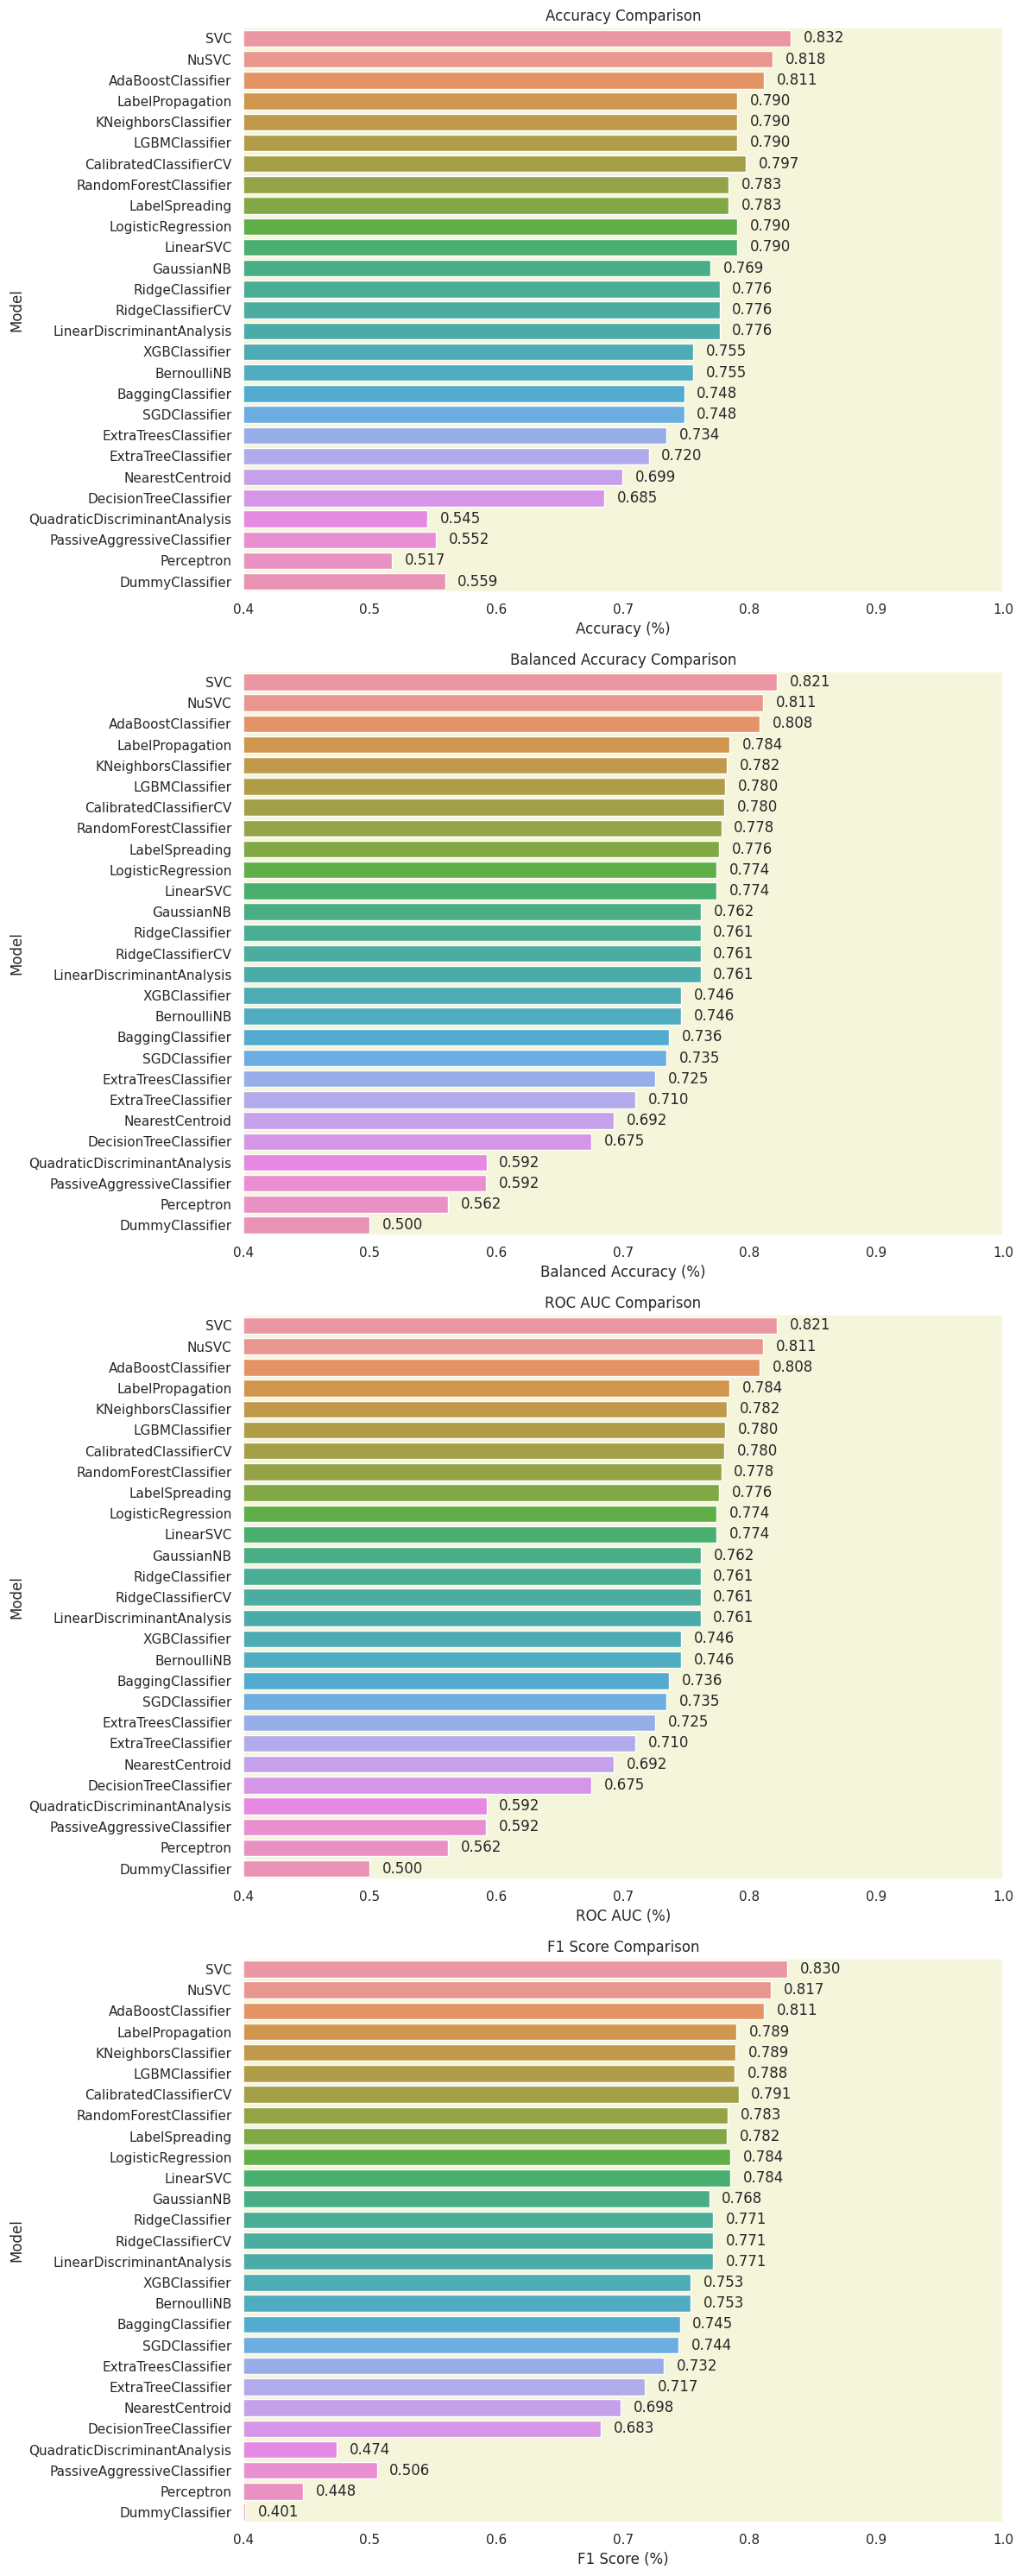

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 30))
metrics = ['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score']

for i, metric in enumerate(metrics):
    plt.subplot(4, 1, i+1)
    ax = sns.barplot(x=models[metric], y=models.index, orient='h')
    plt.title(f'{metric} Comparison')
    plt.xlabel(f'{metric} (%)')
    plt.ylabel('Model')
    
    # Set x-axis to start from 0.40
    plt.xlim(0.40, 1.0)
    
    # Add value labels on the bars
    for j, v in enumerate(models[metric]):
        ax.text(v + 0.01, j, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

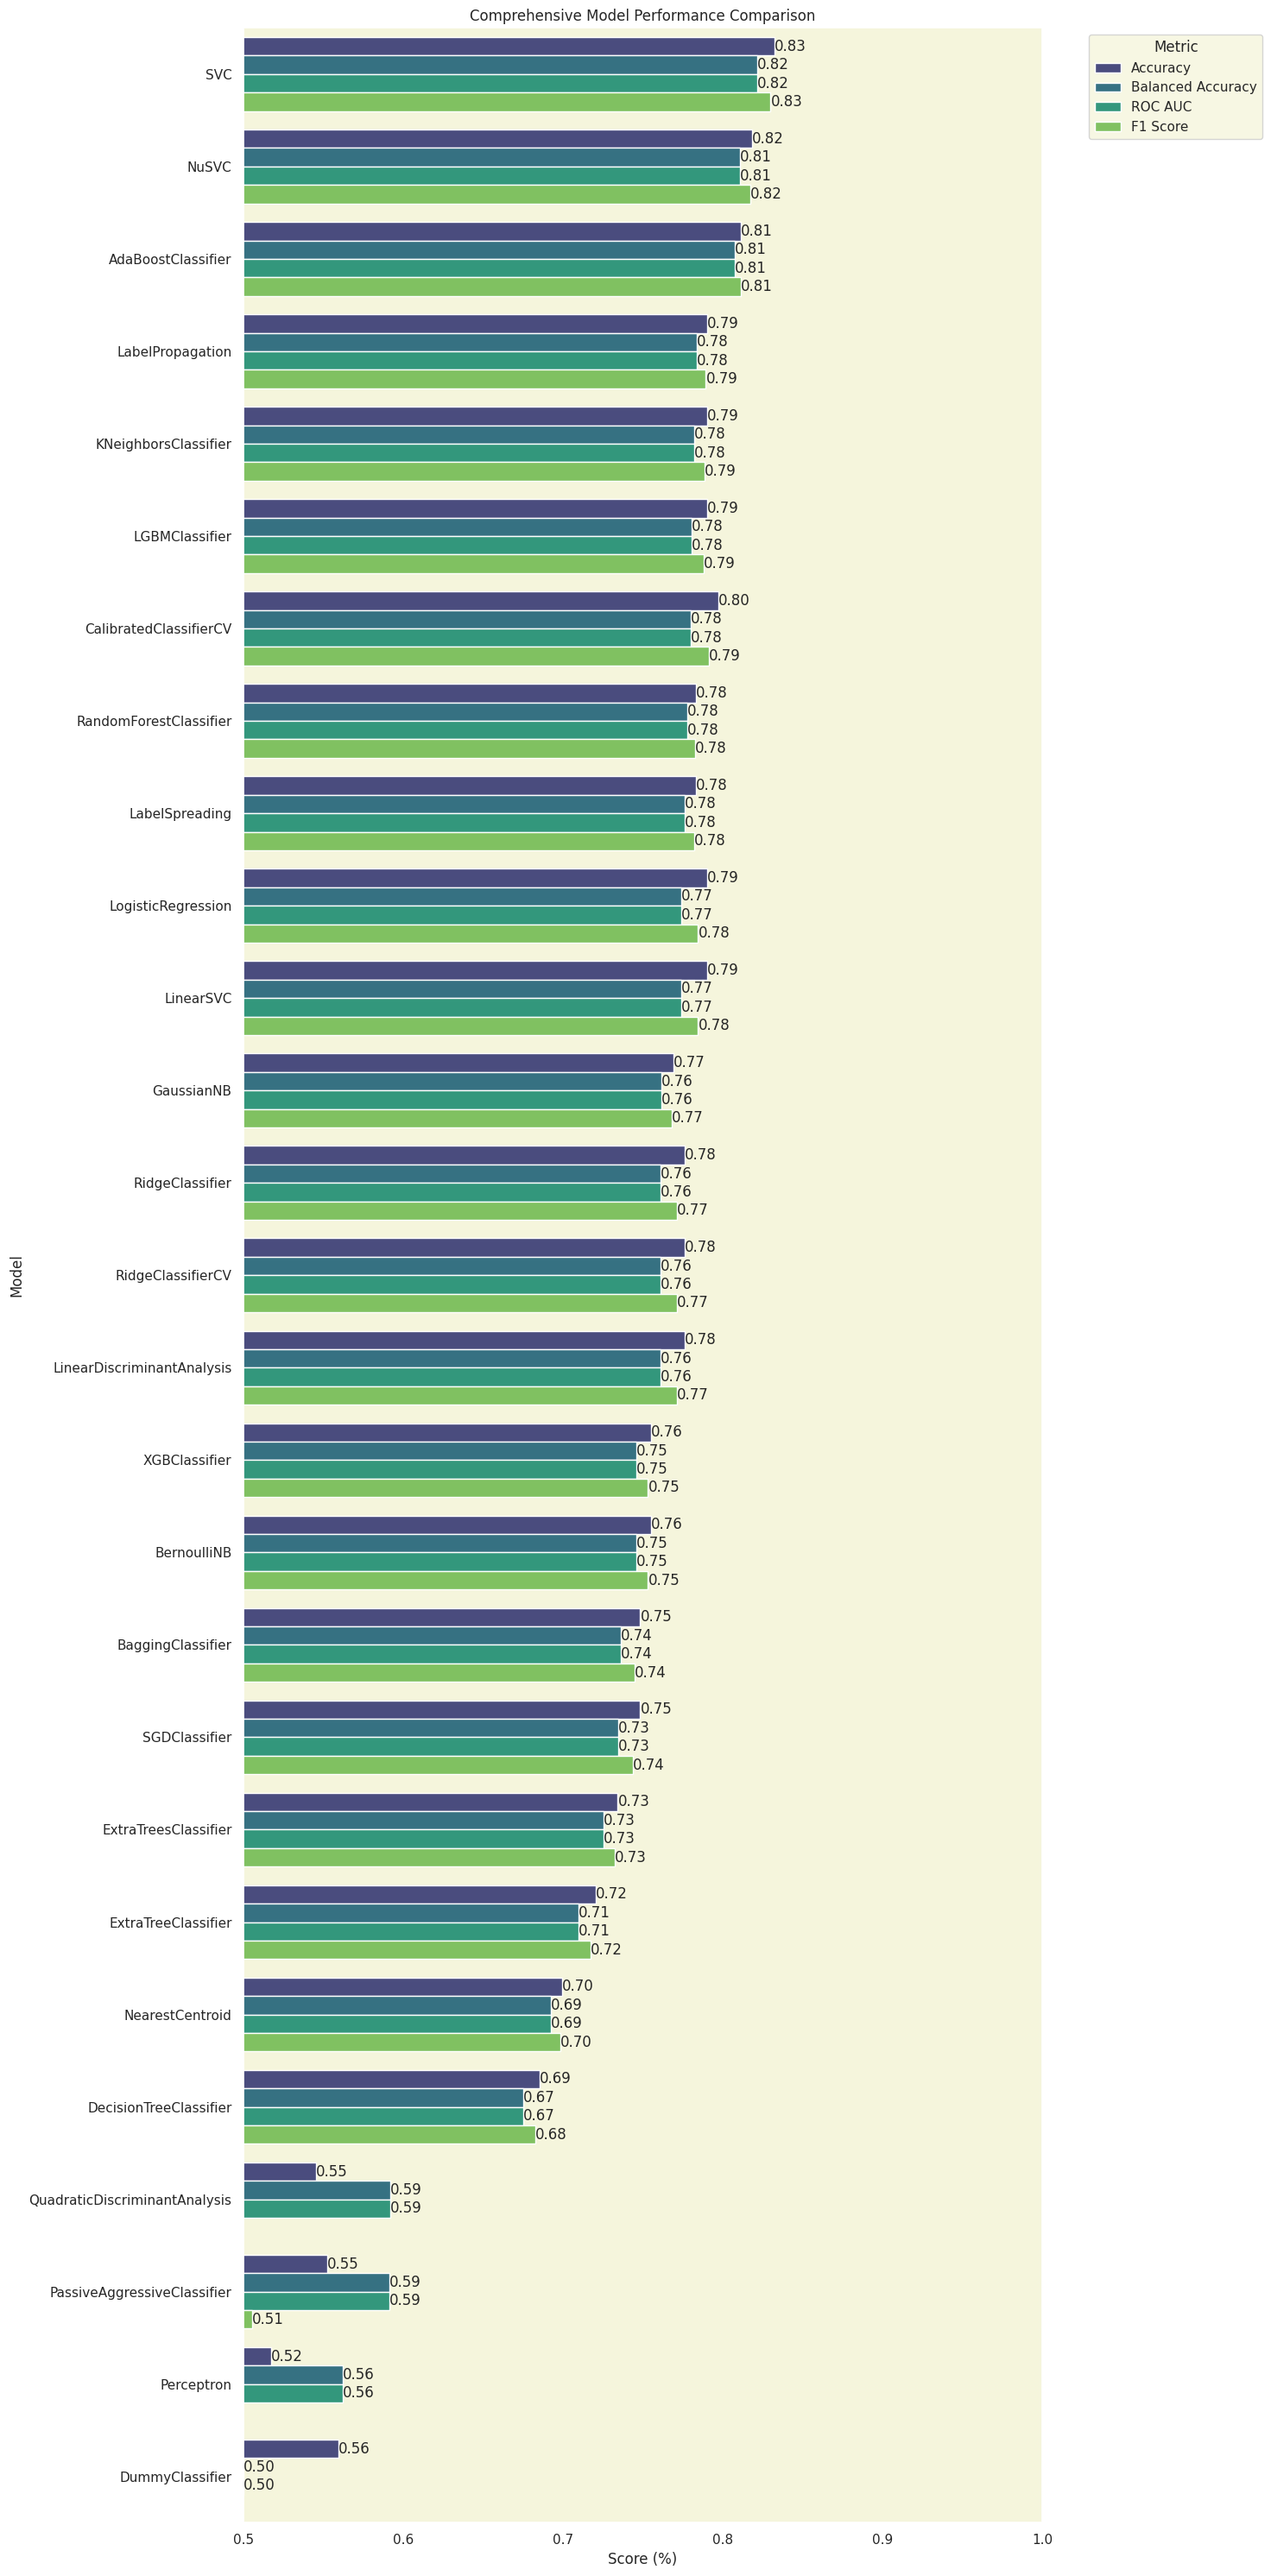

In [191]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'models' and 'metrics' are already defined DataFrames
summary_df = models[metrics].copy()
summary_df['Model'] = models.index
summary_df = summary_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Create a comprehensive visualization
plt.figure(figsize=(15, 30))
barplot = sns.barplot(x='Score', y='Model', hue='Metric', data=summary_df, orient='h', palette='viridis')

# Add values at the edge of the bars
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.2f', label_type='edge')

plt.title('Comprehensive Model Performance Comparison')
plt.xlabel('Score (%)')
plt.ylabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set x-axis to start from 0.50
plt.xlim(0.50, 1.0)

plt.tight_layout()
plt.show()
